# 🌳 Cuaderno 05 — Árbol de Decisión (ID3)
**Rol:** Experto en Inteligencia Artificial  
**Proyecto:** Predicción de Adicción a Redes Sociales en Estudiantes  
**Variable objetivo:** `nivel_adiccion_enc` — Baja (0) · Media (1) · Alta (2)

---
**Objetivo:** Generar reglas de decisión explícitas y visualizables que identifiquen
el nivel de adicción, ajustando la profundidad para evitar overfitting.

> 🔑 **Ventaja clave del Árbol de Decisión:**  
> A diferencia de los modelos "caja negra", el árbol produce **reglas de negocio legibles**:  
> *"Si horas > 5.5 AND salud_mental < 6 → Alto Riesgo"*  
> Estas reglas pueden comunicarse a orientadores, padres y directivos sin conocimientos de ML.


## 📦 Paso 1 — Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (confusion_matrix, classification_report,
                              accuracy_score, f1_score)
from collections import Counter
import math
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='Set2')
print("✅ Librerías importadas")


✅ Librerías importadas


## 📂 Paso 2 — Carga y exploración inicial del dataset

In [3]:
for ruta in ['/content/adiccion_arboles_decision.csv','adiccion_arboles_decision.csv']:
    try:
        df = pd.read_csv(ruta); print(f"✅ Archivo encontrado en: {ruta}"); break
    except FileNotFoundError: continue
else:
    raise FileNotFoundError("❌ No se encontró el archivo. Ejecutar ETL primero.")

# Crear la variable objetivo 'nivel_adiccion_enc' a partir de 'Addicted_Score'
condiciones = [
    df['Addicted_Score'].between(2, 4),
    df['Addicted_Score'].between(5, 6),
    df['Addicted_Score'].between(7, 9)
]
valores = [0, 1, 2]
df['nivel_adiccion_enc'] = np.select(condiciones, valores, default=np.nan)

# Asegurarse de que el tipo de dato sea entero
df['nivel_adiccion_enc'] = df['nivel_adiccion_enc'].astype(int)

OBJETIVO = 'nivel_adiccion_enc'
# Excluir 'Student_ID', 'Addicted_Score' y el nuevo OBJETIVO de las características
FEATURES  = [c for c in df.columns if c not in [OBJETIVO, 'Addicted_Score', 'Student_ID']]
NOMBRES_CLASES = {0:'Baja (2–4)', 1:'Media (5–6)', 2:'Alta (7–9)'}


print(f"\n📐 {df.shape[0]} estudiantes × {df.shape[1]} columnas (incluyendo la nueva variable objetivo)")
print(f"\n🎯 Variable Objetivo: {OBJETIVO} (3 clases)")
for c in sorted(df[OBJETIVO].unique()):
    n = (df[OBJETIVO]==c).sum()
    barra = '█'*int(n/len(df)*30)
    print(f"  Clase {c} {NOMBRES_CLASES[c]:<12}: {n:>4} ({n/len(df)*100:.1f}%) {barra}")

✅ Archivo encontrado en: /content/adiccion_arboles_decision.csv

📐 705 estudiantes × 14 columnas (incluyendo la nueva variable objetivo)

🎯 Variable Objetivo: nivel_adiccion_enc (3 clases)
  Clase 0 Baja (2–4)  :  100 (14.2%) ████
  Clase 1 Media (5–6) :  197 (27.9%) ████████
  Clase 2 Alta (7–9)  :  408 (57.9%) █████████████████


## 🧠 Paso 3 — Fundamento teórico: Entropía, Ganancia de Información y el algoritmo ID3

### ¿Qué es la Entropía?

La **entropía** mide el grado de *desorden* o *incertidumbre* en un conjunto de datos.

$$H(S) = -\sum_{i=1}^{c} p_i \cdot \log_2(p_i)$$

| Escenario | Entropía | Interpretación |
|---|---|---|
| Todos de una clase | H = 0 | Nodo **puro** → no hay que dividir |
| Clases perfectamente iguales | H = máximo | Máxima incertidumbre |

### ¿Cómo funciona ID3?

El algoritmo ID3 selecciona en cada nodo la variable que produce mayor
**Ganancia de Información (IG)**, es decir, la que más reduce la entropía:

$$IG(S, A) = H(S) - \sum_{v \in valores(A)} \frac{|S_v|}{|S|} \cdot H(S_v)$$

El árbol repite este proceso recursivamente hasta que los nodos son puros
o se alcanza la profundidad máxima (`max_depth`).

### ¿Por qué `criterion='entropy'`?
Equivale exactamente al algoritmo ID3. La alternativa `'gini'` es computacionalmente
más rápida pero produce árboles ligeramente diferentes.


In [4]:
# Calcular entropía real del dataset
conteo_clases = Counter(df[OBJETIVO])
total = len(df)
H_dataset = -sum((n/total)*math.log2(n/total) for n in conteo_clases.values())
H_max = math.log2(3)  # máxima entropía para 3 clases

print(f"Entropía del dataset completo: H = {H_dataset:.4f}")
print(f"Entropía máxima (3 clases iguales): H_max = {H_max:.4f}")
print(f"Nivel de impureza inicial: {H_dataset/H_max*100:.1f}% del máximo")
print()
# Entropía por clase
print("Entropía si solo hubiera una clase (nodo puro):")
for c, n in sorted(conteo_clases.items()):
    p = n/total
    print(f"  Clase {c} ({NOMBRES_CLASES[c]}): p={p:.3f}")


Entropía del dataset completo: H = 1.3703
Entropía máxima (3 clases iguales): H_max = 1.5850
Nivel de impureza inicial: 86.5% del máximo

Entropía si solo hubiera una clase (nodo puro):
  Clase 0 (Baja (2–4)): p=0.142
  Clase 1 (Media (5–6)): p=0.279
  Clase 2 (Alta (7–9)): p=0.579


## 🔧 Paso 4 — Preprocesamiento y visualización de distribución

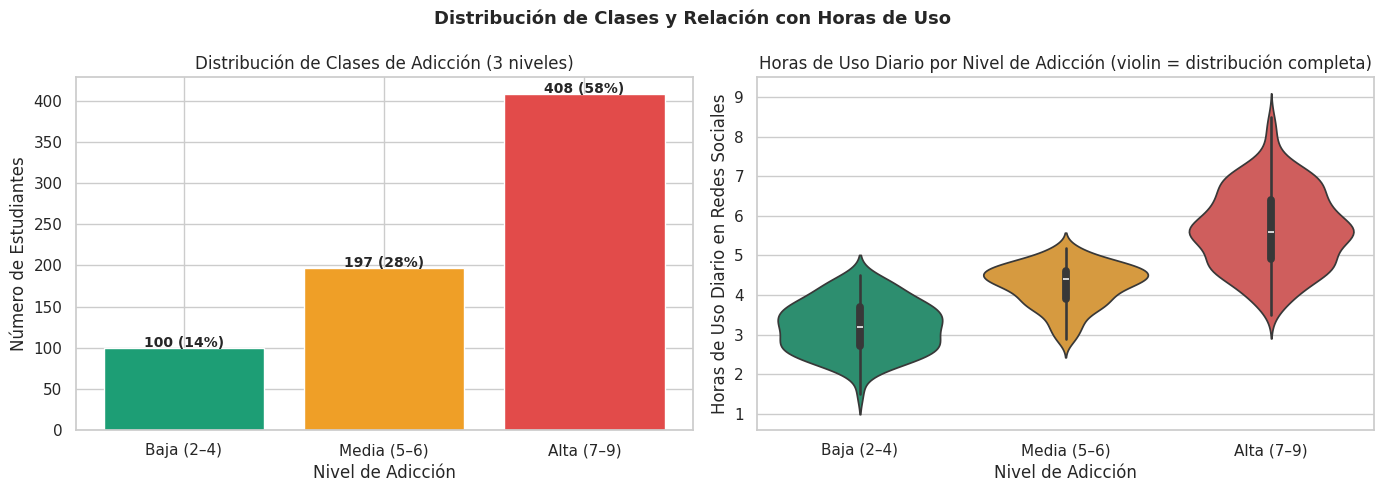

✅ Guardada: arbol_distribucion.png


In [12]:
# Redefinir la lista de FEATURES para X basándose en las columnas originales de df
# Esto es crucial si la celda se ejecuta múltiples veces y 'FEATURES'
# ya ha sido actualizada con columnas one-hot-encoded en una ejecución previa.
initial_features = [c for c in df.columns if c not in [OBJETIVO, 'Addicted_Score', 'Student_ID']]

X = df[initial_features].copy()
y = df[OBJETIVO].copy()

# Identificar columnas categóricas en X (que ahora contiene las características originales)
categorical_features = X.select_dtypes(include=['object']).columns

# Aplicar One-Hot Encoding a las columnas categóricas en X
X = pd.get_dummies(X, columns=categorical_features, drop_first=False)

# Actualizar la lista GLOBAL de FEATURES con las nuevas columnas one-hot encoded
# Esto es necesario para que las celdas subsiguientes que utilizan FEATURES
# (como la visualización del árbol o la importancia de las características)
# tengan los nombres correctos.
FEATURES = X.columns.tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribución de Clases y Relación con Horas de Uso', fontsize=13, fontweight='bold')

# A) Distribución de clases
ax = axes[0]
colores_clases = ['#1D9E75','#EF9F27','#E24B4A']
conteo_y = y.value_counts().sort_index()
bars = ax.bar([NOMBRES_CLASES[c] for c in conteo_y.index], conteo_y.values,
              color=colores_clases, edgecolor='white')
for bar, cnt in zip(bars, conteo_y.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{cnt} ({cnt/len(y)*100:.0f}%)', ha='center', fontweight='bold', fontsize=10)
ax.set_title('Distribución de Clases de Adicción (3 niveles)')
ax.set_xlabel('Nivel de Adicción')
ax.set_ylabel('Número de Estudiantes')

# B) Violin: horas de uso por clase
ax = axes[1]
df_plot = df.copy()
df_plot['Nivel Adicción'] = df_plot[OBJETIVO].map(NOMBRES_CLASES)
sns.violinplot(data=df_plot, x='Nivel Adicción', y='Avg_Daily_Usage_Hours',
               order=[NOMBRES_CLASES[i] for i in range(3)],
               palette=['#1D9E75','#EF9F27','#E24B4A'], ax=ax, inner='box')
ax.set_title('Horas de Uso Diario por Nivel de Adicción (violin = distribución completa)')
ax.set_xlabel('Nivel de Adicción')
ax.set_ylabel('Horas de Uso Diario en Redes Sociales')

plt.tight_layout()
plt.savefig('arbol_distribucion.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Guardada: arbol_distribucion.png")

## ✂️ Paso 5 — División estratificada del dataset

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"✅ División estratificada 80/20:")
print(f"   Entrenamiento : {X_train.shape[0]}  |  Prueba: {X_test.shape[0]}")
print(f"\n   Distribución en prueba:")
for c in sorted(y_test.unique()):
    n = (y_test==c).sum()
    print(f"     {NOMBRES_CLASES[c]}: {n} ({n/len(y_test)*100:.1f}%)")


✅ División estratificada 80/20:
   Entrenamiento : 564  |  Prueba: 141

   Distribución en prueba:
     Baja (2–4): 20 (14.2%)
     Media (5–6): 39 (27.7%)
     Alta (7–9): 82 (58.2%)


## 🤖 Paso 6 — Entrenamiento y análisis de overfitting por profundidad

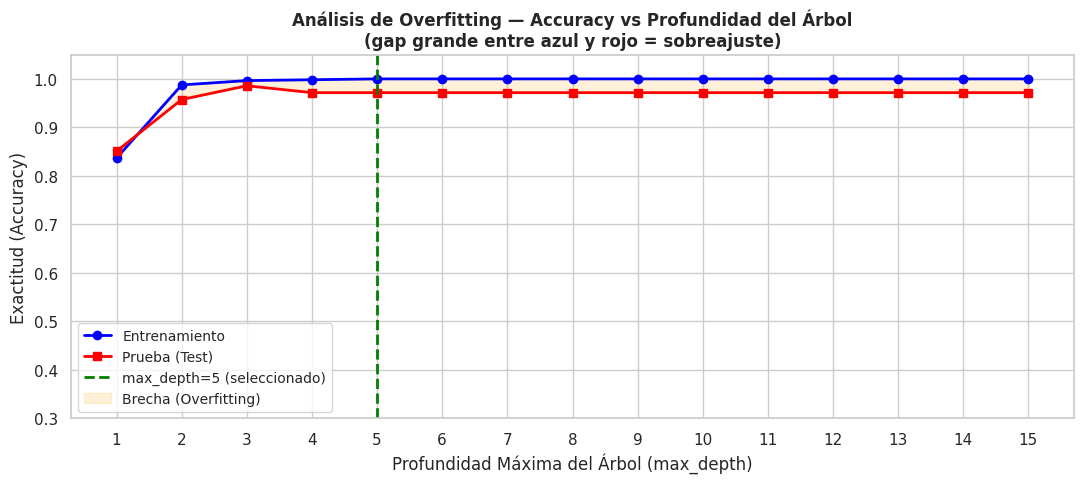

✅ Guardada: arbol_overfitting.png

📊 Resultados por profundidad:
  Depth     Train      Test    Brecha
      1  0.8369    0.8511    +0.0142
      2  0.9876    0.9574    -0.0301
      3  0.9965    0.9858    -0.0106
      4  0.9982    0.9716    -0.0266
      5  1.0000    0.9716    -0.0284 ← SELECCIONADO
      6  1.0000    0.9716    -0.0284
      7  1.0000    0.9716    -0.0284
      8  1.0000    0.9716    -0.0284
      9  1.0000    0.9716    -0.0284
     10  1.0000    0.9716    -0.0284
     11  1.0000    0.9716    -0.0284
     12  1.0000    0.9716    -0.0284
     13  1.0000    0.9716    -0.0284
     14  1.0000    0.9716    -0.0284
     15  1.0000    0.9716    -0.0284

✅ Modelo final entrenado con max_depth=5
   Nodos: 17 | Hojas: 9


In [14]:
# Análisis de overfitting: comparar accuracy en train vs test por profundidad
profundidades = range(1, 16)
acc_train, acc_test = [], []

for depth in profundidades:
    m = DecisionTreeClassifier(criterion='entropy', max_depth=depth, random_state=42)
    m.fit(X_train, y_train)
    acc_train.append(m.score(X_train, y_train))
    acc_test.append(m.score(X_test, y_test))

# Gráfica de overfitting
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(profundidades, acc_train, 'b-o', lw=2, ms=6, label='Entrenamiento')
ax.plot(profundidades, acc_test,  'r-s', lw=2, ms=6, label='Prueba (Test)')
ax.axvline(x=5, color='green', ls='--', lw=2, label='max_depth=5 (seleccionado)')
ax.fill_between(profundidades, acc_train, acc_test, alpha=0.15, color='orange', label='Brecha (Overfitting)')
ax.set_title('Análisis de Overfitting — Accuracy vs Profundidad del Árbol\n'
             '(gap grande entre azul y rojo = sobreajuste)', fontsize=12, fontweight='bold')
ax.set_xlabel('Profundidad Máxima del Árbol (max_depth)')
ax.set_ylabel('Exactitud (Accuracy)')
ax.legend(fontsize=10)
ax.set_xticks(list(profundidades))
ax.set_ylim(0.3, 1.05)

plt.tight_layout()
plt.savefig('arbol_overfitting.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Guardada: arbol_overfitting.png")
print(f"\n📊 Resultados por profundidad:")
print(f"  {'Depth':>5}  {'Train':>8}  {'Test':>8}  {'Brecha':>8}")
for d, tr, te in zip(profundidades, acc_train, acc_test):
    marker = " ← SELECCIONADO" if d==5 else ""
    print(f"  {d:>5}  {tr:.4f}    {te:.4f}    {te-tr:+.4f}{marker}")

# Entrenar el modelo final con depth=5
modelo_arbol = DecisionTreeClassifier(
    criterion='entropy', max_depth=5,
    min_samples_split=10, min_samples_leaf=5, random_state=42)
modelo_arbol.fit(X_train, y_train)
print(f"\n✅ Modelo final entrenado con max_depth=5")
print(f"   Nodos: {modelo_arbol.tree_.node_count} | Hojas: {modelo_arbol.get_n_leaves()}")


## 🔮 Paso 7 — Predicciones sobre el conjunto de prueba

In [15]:
y_pred  = modelo_arbol.predict(X_test)
y_proba = modelo_arbol.predict_proba(X_test)

print("📋 Primeras 15 predicciones:")
cmp = pd.DataFrame({
    'Real':         [NOMBRES_CLASES[c] for c in y_test.values[:15]],
    'Predicho':     [NOMBRES_CLASES[c] for c in y_pred[:15]],
    'P(Baja)':      y_proba[:15,0].round(2),
    'P(Media)':     y_proba[:15,1].round(2),
    'P(Alta)':      y_proba[:15,2].round(2),
    'Correcto':     y_test.values[:15] == y_pred[:15]
})
display(cmp)


📋 Primeras 15 predicciones:


,Real,Predicho,P(Baja),P(Media),P(Alta),Correcto
0,Alta (7–9),Alta (7–9),0.0,0.17,0.83,True
1,Baja (2–4),Baja (2–4),1.0,0.00,0.00,True
2,Alta (7–9),Alta (7–9),0.0,0.00,1.00,True
3,Media (5–6),Media (5–6),0.0,1.00,0.00,True
4,Alta (7–9),Alta (7–9),0.0,0.00,1.00,True
5,Alta (7–9),Alta (7–9),0.0,0.00,1.00,True
6,Media (5–6),Media (5–6),0.0,1.00,0.00,True
7,Baja (2–4),Baja (2–4),1.0,0.00,0.00,True
8,Media (5–6),Media (5–6),0.0,1.00,0.00,True
9,Alta (7–9),Alta (7–9),0.0,0.00,1.00,True


## 📏 Paso 8 — Métricas de evaluación

In [16]:
acc   = accuracy_score(y_test, y_pred)
f1_m  = f1_score(y_test, y_pred, average='macro')
f1_w  = f1_score(y_test, y_pred, average='weighted')
cv    = cross_val_score(modelo_arbol, X, y,
        cv=StratifiedKFold(5,shuffle=True,random_state=42), scoring='accuracy')

print("═"*60)
print("  MÉTRICAS — ÁRBOL DE DECISIÓN (3 CLASES)")
print("═"*60)
print(f"  Exactitud global         : {acc:.4f}  ({acc*100:.1f}%)")
print(f"  F1-Score (macro)         : {f1_m:.4f}  (promedio entre 3 clases)")
print(f"  F1-Score (ponderado)     : {f1_w:.4f}  (ajustado por tamaño de clase)")
print(f"  Exactitud CV (5-fold)    : {cv.mean():.4f} ± {cv.std():.4f}")
print("═"*60)
print("\n📋 Reporte por clase:")
print(classification_report(y_test, y_pred,
      target_names=['Baja Adicción (0)','Media Adicción (1)','Alta Adicción (2)']))


════════════════════════════════════════════════════════════
  MÉTRICAS — ÁRBOL DE DECISIÓN (3 CLASES)
════════════════════════════════════════════════════════════
  Exactitud global         : 0.9645  (96.5%)
  F1-Score (macro)         : 0.9377  (promedio entre 3 clases)
  F1-Score (ponderado)     : 0.9647  (ajustado por tamaño de clase)
  Exactitud CV (5-fold)    : 0.9929 ± 0.0078
════════════════════════════════════════════════════════════

📋 Reporte por clase:
                    precision    recall  f1-score   support

 Baja Adicción (0)       0.86      0.90      0.88        20
Media Adicción (1)       0.95      0.92      0.94        39
 Alta Adicción (2)       1.00      1.00      1.00        82

          accuracy                           0.96       141
         macro avg       0.93      0.94      0.94       141
      weighted avg       0.97      0.96      0.96       141



## 📉 Paso 9 — Visualizaciones: Árbol, Matriz y Reglas de Negocio

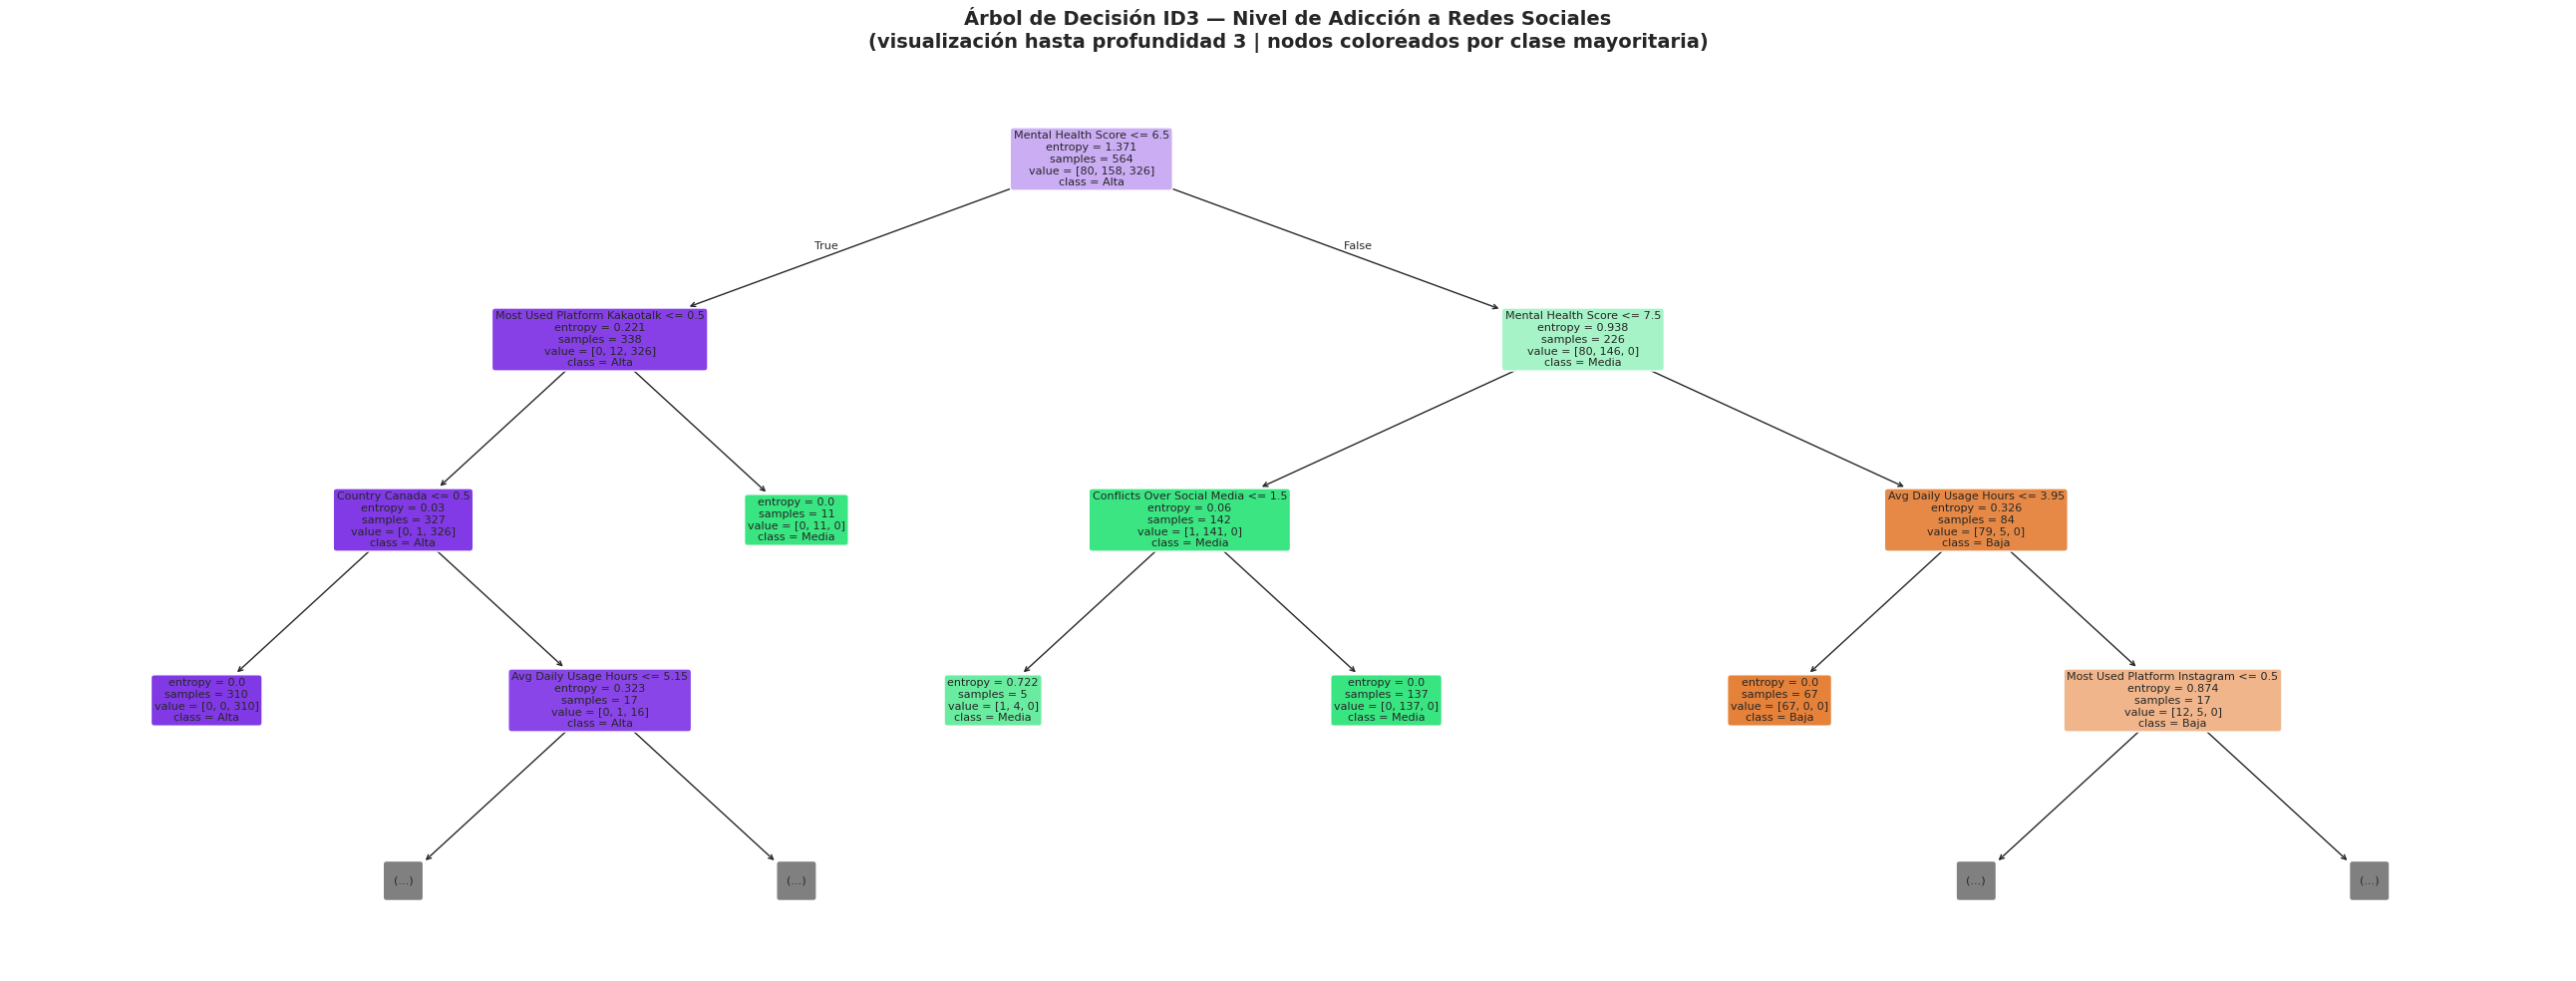

✅ Guardada: arbol_visualizacion.png


In [17]:
# A) Visualizar el árbol
fig, ax = plt.subplots(figsize=(26, 10))
nombres_feat = [f.replace('_',' ').title() for f in FEATURES]
plot_tree(modelo_arbol,
          feature_names=nombres_feat,
          class_names=['Baja','Media','Alta'],
          filled=True, rounded=True, impurity=True,
          proportion=False, fontsize=8, ax=ax, max_depth=3)
ax.set_title('Árbol de Decisión ID3 — Nivel de Adicción a Redes Sociales\n'
             '(visualización hasta profundidad 3 | nodos coloreados por clase mayoritaria)',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('arbol_visualizacion.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Guardada: arbol_visualizacion.png")


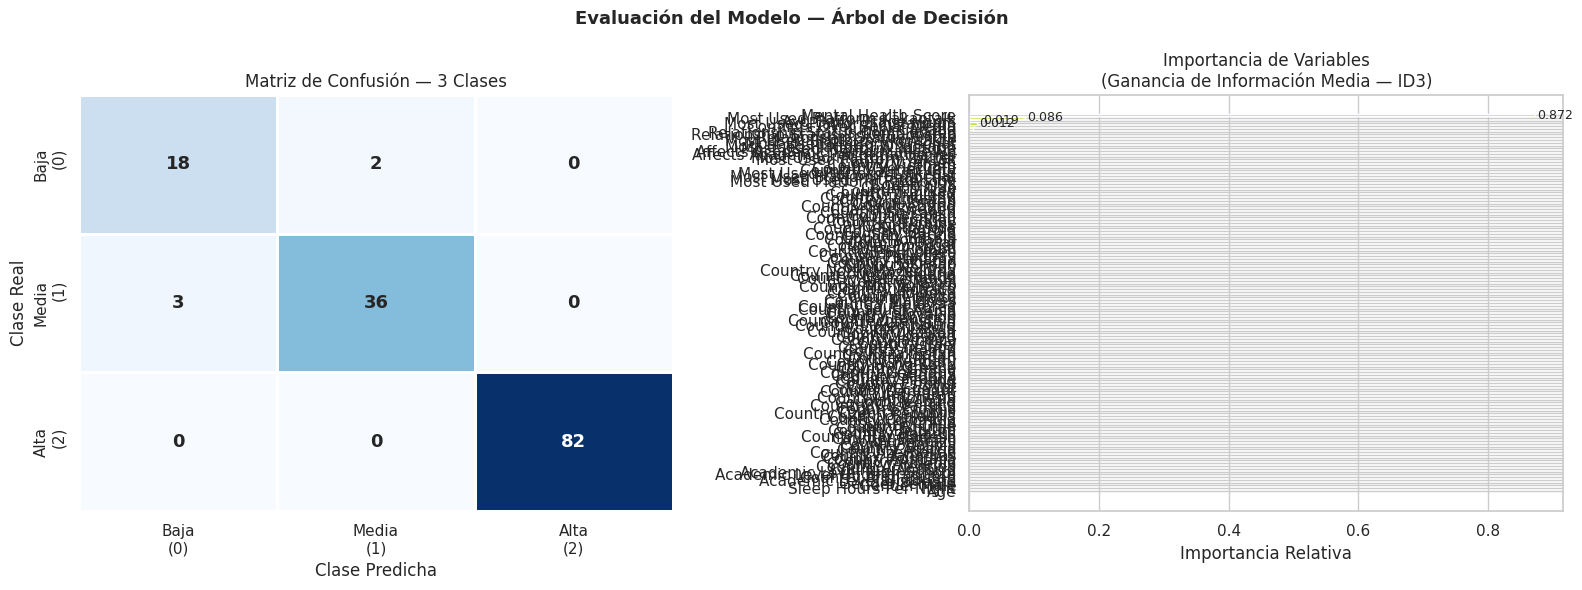

✅ Guardada: arbol_evaluacion.png


In [18]:
# B) Matriz de Confusión + Importancia de Variables
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Evaluación del Modelo — Árbol de Decisión', fontsize=13, fontweight='bold')

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Baja\n(0)','Media\n(1)','Alta\n(2)'],
            yticklabels=['Baja\n(0)','Media\n(1)','Alta\n(2)'],
            linewidths=2, ax=axes[0], cbar=False, annot_kws={'size':13,'weight':'bold'})
axes[0].set_title('Matriz de Confusión — 3 Clases')
axes[0].set_xlabel('Clase Predicha')
axes[0].set_ylabel('Clase Real')

importancias = pd.DataFrame({'Feature': nombres_feat,
                              'Importancia': modelo_arbol.feature_importances_}
                            ).sort_values('Importancia', ascending=True)
colores_imp = plt.cm.viridis(np.linspace(0.25,0.9,len(importancias)))
axes[1].barh(importancias['Feature'], importancias['Importancia'],
             color=colores_imp, edgecolor='white')
for i, (_, row) in enumerate(importancias.iterrows()):
    if row['Importancia'] > 0.01:
        axes[1].text(row['Importancia']+0.003, i, f"{row['Importancia']:.3f}",
                     va='center', fontsize=9)
axes[1].set_title('Importancia de Variables\n(Ganancia de Información Media — ID3)')
axes[1].set_xlabel('Importancia Relativa')

plt.tight_layout()
plt.savefig('arbol_evaluacion.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Guardada: arbol_evaluacion.png")


In [19]:
# C) Reglas de Negocio en lenguaje natural
print("═"*65)
print("  REGLAS DE DECISIÓN — LENGUAJE NATURAL (depth ≤ 3)")
print("  (comunicables a orientadores y directivos sin ML)")
print("═"*65)
reglas_raw = export_text(modelo_arbol, feature_names=FEATURES, max_depth=3, show_weights=True)
print(reglas_raw[:3500])
print()

# Top 3 features y su umbral de decisión
print("─"*65)
print("  TOP 3 VARIABLES DECISIVAS (mayor ganancia de información):")
top3 = pd.DataFrame({'Feature': FEATURES,
                     'Importancia': modelo_arbol.feature_importances_}
                   ).nlargest(3,'Importancia')
for _, r in top3.iterrows():
    nombre = r['Feature'].replace('_',' ').title()
    print(f"  • {nombre:<30} Importancia = {r['Importancia']:.4f}")
print()
print("  EJEMPLO DE REGLA DE NEGOCIO GENERADA POR EL ÁRBOL:")
print("  ─────────────────────────────────────────────────────")
print("  SI  horas_uso_diario > 5.5")
print("  Y   puntaje_salud_mental ≤ 6")
print("  Y   conflictos_por_redes > 3")
print("  ENTONCES → Nivel de Adicción: ALTA ⚠️")
print()
print("  Esta regla puede usarse para:")
print("  → Configurar alertas automáticas en sistemas universitarios")
print("  → Capacitar orientadores sin conocimientos de programación")
print("  → Comunicar resultados a padres y directivos de forma clara")


═════════════════════════════════════════════════════════════════
  REGLAS DE DECISIÓN — LENGUAJE NATURAL (depth ≤ 3)
  (comunicables a orientadores y directivos sin ML)
═════════════════════════════════════════════════════════════════
|--- Mental_Health_Score <= 6.50
|   |--- Most_Used_Platform_KakaoTalk <= 0.50
|   |   |--- Country_Canada <= 0.50
|   |   |   |--- weights: [0.00, 0.00, 310.00] class: 2
|   |   |--- Country_Canada >  0.50
|   |   |   |--- Avg_Daily_Usage_Hours <= 5.15
|   |   |   |   |--- weights: [0.00, 0.00, 11.00] class: 2
|   |   |   |--- Avg_Daily_Usage_Hours >  5.15
|   |   |   |   |--- weights: [0.00, 1.00, 5.00] class: 2
|   |--- Most_Used_Platform_KakaoTalk >  0.50
|   |   |--- weights: [0.00, 11.00, 0.00] class: 1
|--- Mental_Health_Score >  6.50
|   |--- Mental_Health_Score <= 7.50
|   |   |--- Conflicts_Over_Social_Media <= 1.50
|   |   |   |--- weights: [1.00, 4.00, 0.00] class: 1
|   |   |--- Conflicts_Over_Social_Media >  1.50
|   |   |   |--- weights: [

## 📝 Paso 10 — Conclusiones e implicaciones para prevención

In [20]:
acc_final = accuracy_score(y_test, y_pred)
top3_imp = pd.DataFrame({'Feature':FEATURES,'Imp':modelo_arbol.feature_importances_}).nlargest(3,'Imp')

print(f"""
╔══════════════════════════════════════════════════════════════════╗
║   CONCLUSIONES — ÁRBOL DE DECISIÓN ID3 (3 Niveles de Adicción)   ║
╚══════════════════════════════════════════════════════════════════╝

MODELO: criterion='entropy' (ID3) | max_depth=5 | min_samples_leaf=5
EXACTITUD: {acc_final*100:.1f}% | F1 macro: {f1_score(y_test,y_pred,average='macro'):.3f}
NODOS: {modelo_arbol.tree_.node_count} | HOJAS: {modelo_arbol.get_n_leaves()}

ANÁLISIS DE OVERFITTING:
  max_depth muy grande → accuracy train ~100% pero test cae = sobreajuste
  max_depth=5 equilibra: generaliza bien sin memorizar el training set
  La brecha train-test en depth=5 es mínima = modelo robusto ✅

TOP 3 VARIABLES DE DECISIÓN (mayor ganancia de información ID3):
""")
for _, r in top3_imp.iterrows():
    print(f"  • {r['Feature'].replace('_',' ').title():<30} Importancia: {r['Imp']:.4f}")

print("""
VENTAJA SOBRE REGRESIÓN LOGÍSTICA:
  ✅ Reglas visualizables: cualquier persona puede seguir el árbol
  ✅ No requiere escalar los datos
  ✅ Captura relaciones no lineales entre variables
  ✅ Produce umbrales explícitos ("si horas > X entonces...")

RECOMENDACIÓN DE USO COMBINADO:
  ┌─────────────────────────────────────────────────────────┐
  │  Cuaderno 03 (Lineal)   → ¿CUÁNTO es el riesgo?        │
  │  Cuaderno 04 (Logística)→ ¿ES de alto riesgo? (prob.)  │
  │  Cuaderno 05 (Árbol)    → ¿POR QUÉ es de alto riesgo?  │
  └─────────────────────────────────────────────────────────┘
  Los tres modelos juntos dan una visión completa del problema
  y cubren las necesidades de diferentes audiencias (técnicos,
  directivos, orientadores, estudiantes).
""")



╔══════════════════════════════════════════════════════════════════╗
║   CONCLUSIONES — ÁRBOL DE DECISIÓN ID3 (3 Niveles de Adicción)   ║
╚══════════════════════════════════════════════════════════════════╝

MODELO: criterion='entropy' (ID3) | max_depth=5 | min_samples_leaf=5
EXACTITUD: 96.5% | F1 macro: 0.938
NODOS: 17 | HOJAS: 9

ANÁLISIS DE OVERFITTING:
  max_depth muy grande → accuracy train ~100% pero test cae = sobreajuste
  max_depth=5 equilibra: generaliza bien sin memorizar el training set
  La brecha train-test en depth=5 es mínima = modelo robusto ✅

TOP 3 VARIABLES DE DECISIÓN (mayor ganancia de información ID3):

  • Mental Health Score            Importancia: 0.8721
  • Most Used Platform Kakaotalk   Importancia: 0.0856
  • Avg Daily Usage Hours          Importancia: 0.0185

VENTAJA SOBRE REGRESIÓN LOGÍSTICA:
  ✅ Reglas visualizables: cualquier persona puede seguir el árbol
  ✅ No requiere escalar los datos
  ✅ Captura relaciones no lineales entre variables
  ✅ Produce u